In [ ]:
# imports
import warnings
from importlib import reload as mreload
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatter, FuncFormatter
import seaborn as sns
import dispersion as dsp

In [ ]:
twopi = 2*np.pi

### Parameter estimation

#### sources:
- Nayar et al., Surface Tension of Seawater (2014)
- Bock & Frew, Static and Dynamic Response (1993)
- Schmidt & Schneider, The effect of surface films on the air-sea gas exchange (2011)
- Pogorzelski & Kogut, Static and dynamic properties of surfactant films (2001)
- Pogorzelski & Kogut, Kinetics of marine surfactant adsorption at an air/water interface (2001b)
- Boniewicz-Szmyt & Pogorzelski, Evolution of natural sea surface films (2018)
- Laxague et al., The suppression of ocean waves by biogenic slicks (2024)

#### Pogorzelski & Kogut conversion script

In [ ]:
# Pogorzelski & Kogut 2001, Table 2.
# Units:
#   dt, tau1, tau2 in seconds
#   E0, E_isoth, E_d, E_i in mN/m
#   theta_deg in degrees
#   dA_over_A dimensionless

# Derived quantities per Pogorzelski's identification ω₀ ≡ 1/(2τ₁), ω ≡ 2π/Δt:
#   omega_0 = 1 / (2 * s["tau1"])
#   omega   = 2 * math.pi / s["dt"]
#   W       = (omega_0 / omega) ** 0.5
#   eta_d   = s["E_i"] / omega        # surface dilational viscosity, mN·s/m
pogorzelski_2001_table2 = [
    # Baltic Sea
    {"region": "Baltic",        "station": "Brzeźno",          "date": "1999-07-12", "dA_over_A": 0.13, "dt": 0.37, "tau1": 2.00, "tau2": 21.9,  "E0": 19.07, "E_isoth": 29.12, "E_d": 16.83, "E_i": 1.80, "theta_deg": 6.1},
    {"region": "Baltic",        "station": "Jelitkowo",        "date": "1997-11-29", "dA_over_A": 0.12, "dt": 0.70, "tau1": 2.43, "tau2": 12.16, "E0": 12.08, "E_isoth": 25.81, "E_d": 10.32, "E_i": 1.34, "theta_deg": 7.4},
    {"region": "Baltic",        "station": "Jelitkowo",        "date": "1999-07-09", "dA_over_A": 0.10, "dt": 0.63, "tau1": 2.80, "tau2": 12.20, "E0": 29.65, "E_isoth": 22.94, "E_d": 25.89, "E_i": 3.36, "theta_deg": 7.4},
    {"region": "Baltic",        "station": "Orłowo",           "date": "1998-08-19", "dA_over_A": 0.15, "dt": 0.22, "tau1": 1.30, "tau2": 14.91, "E0": 21.46, "E_isoth": 20.35, "E_d": 18.94, "E_i": 2.02, "theta_deg": 6.1},
    {"region": "Baltic",        "station": "Orłowo",           "date": "1999-07-15", "dA_over_A": 0.08, "dt": 0.32, "tau1": 1.61, "tau2": 10.14, "E0": 27.50, "E_isoth": 24.48, "E_d": 24.14, "E_i": 2.68, "theta_deg": 6.3},
    {"region": "Baltic",        "station": "Sopot",            "date": "1998-09-23", "dA_over_A": 0.08, "dt": 0.37, "tau1": 2.56, "tau2": 10.21, "E0": 21.49, "E_isoth": 23.12, "E_d": 19.32, "E_i": 1.84, "theta_deg": 5.7},
    {"region": "Baltic",        "station": "Sopot",            "date": "1999-07-06", "dA_over_A": 0.21, "dt": 0.40, "tau1": 2.86, "tau2": 16.60, "E0": 22.01, "E_isoth": 29.22, "E_d": 19.72, "E_i": 1.88, "theta_deg": 5.4},
    # Mediterranean Sea
    {"region": "Mediterranean", "station": "Livorno",          "date": "1997-11-20", "dA_over_A": 0.23, "dt": 1.10, "tau1": 1.97, "tau2": 25.60, "E0":  3.57, "E_isoth":  5.72, "E_d":  2.86, "E_i": 0.49, "theta_deg": 9.8},
    # Inland Waters
    {"region": "Inland",        "station": "Motława river",    "date": "1998-08-20", "dA_over_A": 0.15, "dt": 0.32, "tau1": 2.03, "tau2": 13.26, "E0": 19.55, "E_isoth": 23.24, "E_d": 17.44, "E_i": 1.73, "theta_deg": 5.7},
    {"region": "Inland",        "station": "Motława",          "date": "2000-06-13", "dA_over_A": 0.13, "dt": 0.33, "tau1": 1.65, "tau2": 11.80, "E0": 20.65, "E_isoth": 24.16, "E_d": 18.48, "E_i": 2.75, "theta_deg": 5.7},
    {"region": "Inland",        "station": "Martwa Wisła",     "date": "1999-07-16", "dA_over_A": 0.11, "dt": 0.19, "tau1": 1.14, "tau2":  5.60, "E0": 28.66, "E_isoth": 26.15, "E_d": 25.44, "E_i": 2.62, "theta_deg": 5.9},
    {"region": "Inland",        "station": "Oliwa stream",     "date": "1999-07-25", "dA_over_A": 0.16, "dt": 0.33, "tau1": 1.91, "tau2": 12.75, "E0": 21.87, "E_isoth": 25.85, "E_d": 19.86, "E_i": 1.95, "theta_deg": 5.8},
    {"region": "Inland",        "station": "Jasień lake",      "date": "1999-07-13", "dA_over_A": 0.07, "dt": 0.35, "tau1": 1.36, "tau2":  8.65, "E0": 28.66, "E_isoth": 29.65, "E_d": 24.70, "E_i": 3.08, "theta_deg": 7.1},
]

# Pogorzelski & Kogut 2001b, Oceanologia 43:389-404, Table 1. Model based on Eastoe et al. (2000, 2001)
# Units per original table header:
#   Gamma_eq:    1e-10 mol/cm^2
#   D_eff_over_D: 1e-2 (dimensionless ratio)
#   A, B:        short- and long-time fit coefficients of pi(t)
#   E_a_over_RT: dimensionless
#   U10:         m/s (wind speed)
pogorzelski_2001b_table1 = [
    # Baltic Sea
    {"region": "Baltic",        "station": "Jelitkowo",        "date": "2000-11-14", "T_C": 18.5, "A": 328.12, "B":  6.36, "pi_eq":  6.9, "Gamma_eq": 2.85, "D_eff_over_D": 0.1911, "E_a_over_RT": 1.65, "U10": 3.0},
    {"region": "Baltic",        "station": "Jelitkowo",        "date": "2001-04-04", "T_C": 14.7, "A": 110.60, "B": 12.00, "pi_eq":  5.8, "Gamma_eq": 2.42, "D_eff_over_D": 0.1568, "E_a_over_RT": 1.85, "U10": 2.0},
    {"region": "Baltic",        "station": "Jelitkowo",        "date": "2001-05-24", "T_C": 19.0, "A": 256.60, "B": 10.81, "pi_eq": 12.9, "Gamma_eq": 5.31, "D_eff_over_D": 0.0278, "E_a_over_RT": 3.58, "U10": 3.7},
    {"region": "Baltic",        "station": "Jelitkowo",        "date": "2001-07-25", "T_C": 23.3, "A": 363.20, "B": 16.31, "pi_eq": 11.2, "Gamma_eq": 4.55, "D_eff_over_D": 0.2223, "E_a_over_RT": 1.50, "U10": 9.7},
    {"region": "Baltic",        "station": "Orłowo",           "date": "2001-04-12", "T_C": 17.9, "A": 150.68, "B":  0.80, "pi_eq":  2.2, "Gamma_eq": 0.93, "D_eff_over_D": 0.0532, "E_a_over_RT": 2.84, "U10": 5.0},
    {"region": "Baltic",        "station": "Sopot",            "date": "2001-04-14", "T_C": 17.4, "A": 247.48, "B":  3.50, "pi_eq":  6.6, "Gamma_eq": 2.54, "D_eff_over_D": 0.0532, "E_a_over_RT": 2.93, "U10": 3.5},
    {"region": "Baltic",        "station": "Brzeźno",          "date": "2001-04-18", "T_C": 16.4, "A":  68.02, "B":  4.40, "pi_eq":  3.0, "Gamma_eq": 1.24, "D_eff_over_D": 0.1129, "E_a_over_RT": 2.18, "U10": 4.0},
    {"region": "Baltic",        "station": "Brzeźno",          "date": "2001-08-01", "T_C": 22.2, "A": 298.35, "B":  2.10, "pi_eq":  7.8, "Gamma_eq": 3.18, "D_eff_over_D": 0.0105, "E_a_over_RT": 4.55, "U10": 3.2},
    {"region": "Baltic",        "station": "Gdynia",           "date": "2001-04-25", "T_C": 19.5, "A":  84.46, "B":  0.60, "pi_eq":  4.8, "Gamma_eq": 1.99, "D_eff_over_D": 0.0008, "E_a_over_RT": 7.10, "U10": 2.2},
    {"region": "Baltic",        "station": "Oksywie",          "date": "1991-04-26", "T_C":  7.2, "A":  59.68, "B": 13.80, "pi_eq":  1.5, "Gamma_eq": 1.99, "D_eff_over_D": 0.1468, "E_a_over_RT": 1.91, "U10": 0.8},
    {"region": "Baltic",        "station": "Oksywie",          "date": "1991-04-26", "T_C":  7.2, "A":  62.66, "B": 12.50, "pi_eq":  0.9, "Gamma_eq": 1.99, "D_eff_over_D": 0.1327, "E_a_over_RT": 2.02, "U10": 4.1},
    {"region": "Baltic",        "station": "Oksywie",          "date": "1991-04-26", "T_C":  7.2, "A":  35.08, "B":  4.80, "pi_eq":  0.6, "Gamma_eq": 1.99, "D_eff_over_D": 0.0061, "E_a_over_RT": 5.09, "U10": 13.6},
    # Inland Waters
    {"region": "Inland",        "station": "Oliwa stream",     "date": "2001-04-05", "T_C": 17.9, "A": 261.76, "B":  2.80, "pi_eq":  6.1, "Gamma_eq": 2.52, "D_eff_over_D": 0.0389, "E_a_over_RT": 3.25, "U10": 1.0},
    {"region": "Inland",        "station": "Martwa Wisła",     "date": "2001-08-02", "T_C": 23.1, "A": 169.66, "B":  1.35, "pi_eq":  2.6, "Gamma_eq": 1.05, "D_eff_over_D": 0.1175, "E_a_over_RT": 2.14, "U10": 2.4},
    {"region": "Inland",        "station": "Motława",          "date": "2001-08-02", "T_C": 22.7, "A": 144.00, "B":  2.41, "pi_eq":  5.8, "Gamma_eq": 2.36, "D_eff_over_D": 0.0106, "E_a_over_RT": 4.54, "U10": 2.1},
    {"region": "Inland",        "station": "Jasień lake",      "date": "2001-09-05", "T_C": 20.0, "A": 247.97, "B":  0.78, "pi_eq":  6.7, "Gamma_eq": 2.75, "D_eff_over_D": 0.0018, "E_a_over_RT": 6.32, "U10": 0.0},
    # Mediterranean Sea
    {"region": "Mediterranean", "station": "Livorno",          "date": "1993-06-24", "T_C": 23.0, "A":   None, "B":  None, "pi_eq": 11.0, "Gamma_eq": 4.47, "D_eff_over_D": 0.0080, "E_a_over_RT": 4.32, "U10": None},
    {"region": "Mediterranean", "station": "Livorno",          "date": "1991-06-27", "T_C": 24.0, "A":  46.78, "B": 16.41, "pi_eq":  6.7, "Gamma_eq": 2.55, "D_eff_over_D": 0.0375, "E_a_over_RT": 3.28, "U10": 7.0},
]

for s in pogorzelski_2001_table2:
    s["omega_0"] = 1.0 / (2.0 * s["tau1"])          # rad/s
    s["omega"]   = 2.0 * np.pi / s["dt"]          # rad/s
    s["Omega"]   = (s["omega_0"] / s["omega"]) ** 0.5
    s["eta_d"]   = s["E_i"] / s["omega"]            # mN·s/m

#### various parameter plots

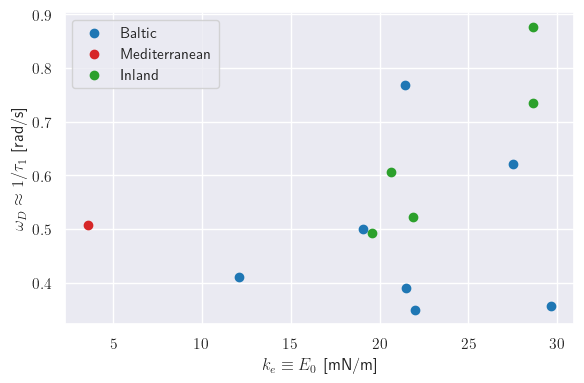

In [ ]:
colors = {"Baltic": "tab:blue", "Mediterranean": "tab:red", "Inland": "tab:green"}

fig, ax = plt.subplots(figsize=(6, 4))
for s in pogorzelski_2001_table2:
    ax.scatter(s["E0"], 1 / s["tau1"], c=colors[s["region"]], label=s["region"])

handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys())

ax.set_xlabel(r"$k_e \equiv E_0$ [mN/m]")
ax.set_ylabel(r"$\omega_D \approx 1/\tau_1$ [rad/s]")
plt.tight_layout()
plt.show()

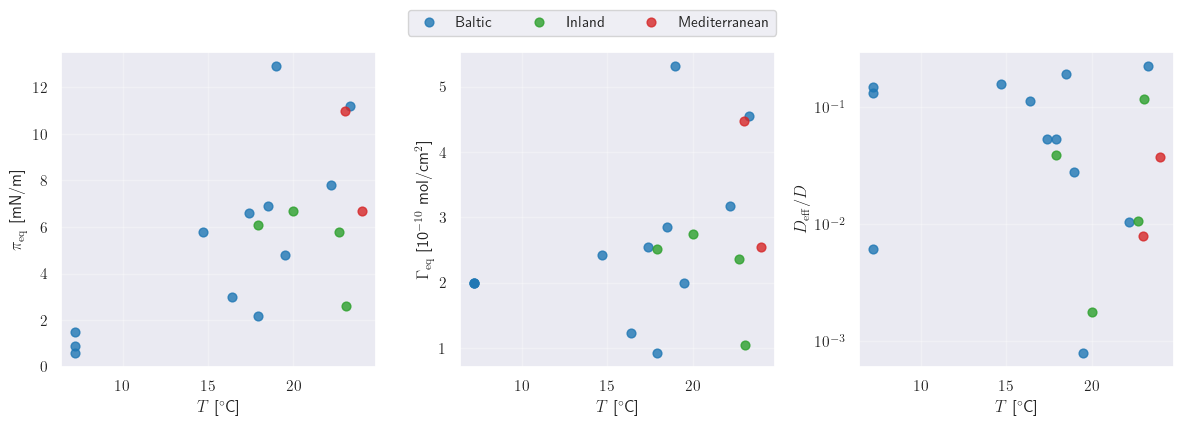

In [ ]:
colors = {"Baltic": "tab:blue", "Mediterranean": "tab:red", "Inland": "tab:green"}
params = [
    ("pi_eq",         r"$\pi_{\mathrm{eq}}$ [mN/m]",          "linear"),
    ("Gamma_eq",      r"$\Gamma_{\mathrm{eq}}$ [10$^{-10}$ mol/cm$^2$]", "linear"),
    ("D_eff_over_D",  r"$D_{\mathrm{eff}}/D$",                "log")
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
for ax, (key, ylabel, yscale) in zip(axes.flat, params):
    for s in pogorzelski_2001b_table1:
        if s[key] is None or s["T_C"] is None:
            continue
        ax.scatter(s["T_C"], s[key], c=colors[s["region"]], label=s["region"], s=40, alpha=0.8)
    ax.set_ylabel(ylabel)
    ax.set_yscale(yscale)
    ax.grid(alpha=0.3)
    ax.set_xlabel(r"$T$ [$^\circ$C]")

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08))
fig.tight_layout()
plt.show()

In [ ]:
# fixed parameters 
try:
    import CoolProp.CoolProp as CP
    T_room = 294.07     # See Nayar (2014), table 1, line 13
    p0     = sp.constants.atm
    rho_   = CP.PropsSI('D',         'T', T_room, 'P', p0, 'Water')
    nu_    = CP.PropsSI('VISCOSITY', 'T', T_room, 'P', p0, 'Water') / rho_
    print(f'CoolProp:  rho={rho_:.4f} kg/m^3   nu={nu_:.4e} m^2/s')
except ImportError:
    warnings.warn('CoolProp not found — using tabulated values.')
    rho_, nu_ = 1025.0, 1.05e-6

pi = np.pi

PARAMS_POLLUTED = dict(
    H     = 100,    # m, arbitrarily large depth.
    rho   = rho_,
    nu    = nu_,
    g     = sp.constants.g,
    T0    = 0.0735, # N/m       surfactant-free seawater surface tension at ~20
                    # degrees celcius, based on Nayar (2014), table 1, line 13.
    delT  = 0.005,  # N/m       delT = T0 - T. Estimated from table 1 in 
                    # Pogorzelski (2001b), and in deviation from Bock (1993),
                    # where they claim the typical value to be one order of
                    # magnitude smaller than that (0.5mN/m). Schmidt & Schneider
                    # (2011) Show high variability, 0.5mN/m at about the median 
                    # and high values are a bit over 10mN/m. Laxague, Zappa,
                    # Soumya & Wurl (2024) quote an estimate higher than what I 
                    # take here.
    k_e   = 0.02,   # N/m       dilatational elasticity. Typical value from
                    # table 2 in Pogorzelski (2001). Note that the only value
                    # from mediterranean water is an outlier. On the other hand,
                    # this is about the median for an essentially coastal
                    # dataset. Open sea might give lower values, e.g. Laxague 
                    # (2024) gives a 9.4mN/m estimate for their open sea sample.
    D = 1e-10,      # m^2/s     effective bulk diffusivity. Rough estimation 
                    # based on table 1 in Pogorzelski (2001b), based on the 
                    # method of Eastoe et al. (2000, 2001). Presumably at 20
                    # degrees celcius the effective diffusivity is even lower.
    kappa = 1e-5,   # m         surface-bulk partition length. Calculated from 
                    # D_eff and a rough estimation of the diffusive decay time
                    # t_D = kappa^2/D_eff ~ t_1 (see Pogorzelski (2001)) at 1s.
)
PARAMS_CLEAN = {**PARAMS_POLLUTED, 'k_e': 0.0}

# Wavenumber grid:  0.002 < k/2pi < 0.2  mm^{-1}  (logspaced)
kover2pi = np.logspace(np.log10(0.002), np.log10(0.2), 1000)  # mm^{-1}
k_arr    = kover2pi * 2*pi * 1e3                              # rad/m
lam_mm   = 1.0 / kover2pi                                     # mm

print('\nParameters:', PARAMS_POLLUTED)
print(f'k/2pi range: {kover2pi[0]:.3f} – {kover2pi[-1]:.3f} mm^-1')
print(f'lambda range: {lam_mm[-1]:.0f} – {lam_mm[0]:.0f} mm')

CoolProp:  rho=998.0128 kg/m^3   nu=9.8138e-07 m^2/s

Parameters: {'H': 100, 'rho': 998.0127975779408, 'nu': 9.8137767548752e-07, 'g': 9.80665, 'T0': 0.0735, 'delT': 0.005, 'k_e': 0.02, 'D': 1e-10, 'kappa': 1e-05}
k/2pi range: 0.002 – 0.200 mm^-1
lambda range: 5 – 500 mm


### Dispersion plots

In [ ]:
ks = np.logspace(np.log10(0.2*twopi), np.log10(200*twopi), 200)  # rad/m

In [ ]:
from ipywidgets import interact, FloatLogSlider, FloatSlider
import numpy as np, matplotlib.pyplot as plt

def _sqrt_rp(z):
    s = np.sqrt(z); return np.where(s.real >= 0, s, -s)

ks = np.logspace(np.log10(2), np.log10(1500), 400)
g = 9.81

def plot_terms(f, rho, nu, T0, k_e, D, kappa):
    omega = f * 2 * np.pi
    a = _sqrt_rp(ks**2 - 1j*omega/nu)
    b = _sqrt_rp(ks**2 - 1j*omega/D)
    r = a/ks
    gamma_d  = D*b/kappa
    gamma_nu = nu*ks**2
    gamma_e  = k_e*ks/(rho*nu)
    w0sq     = g*ks + T0*ks**3/rho
    
    t1 = (gamma_e/gamma_d) * r * omega**2
    t2 = -(gamma_e/gamma_d) * (r-1) * w0sq
    t3 = (1 - 1j*omega/gamma_d) * (r**2 + 1) * omega**2
    t4 = (1 - 1j*omega/gamma_d) * 2j * (r-1)**2 * gamma_nu * omega
    t5 = -(1 - 1j*omega/gamma_d) * (r**2 - 1) * w0sq

    fig, ax = plt.subplots(figsize=(9, 5))
    for t, lab in [
        (t1-t2, r'$(\gamma_e/\gamma_d)\,r\,\omega^2$'),
        (t3-t5, r'$(1-i\omega/\gamma_d)(r^2+1)\omega^2$'),
        (t4, r'$(1-i\omega/\gamma_d)\,2i(r-1)^2\gamma_\nu\omega$')
    ]:
        ax.loglog(ks, np.abs(t), label=lab)
    ax.set(xlabel='k [rad/m]', ylabel='|term|', title=f'ω = {f:.2f} Hz')
    ax.legend(fontsize=8, loc='lower right'); ax.grid(alpha=0.3, which='both')
    plt.show()

interact(plot_terms,
    f = FloatSlider   (value=15,   base=10, min=5,   max=50,   step=0.05),
    rho   = FloatSlider   (value=1000,           min=500, max=1500, step=10),
    nu    = FloatLogSlider(value=1e-6,  base=10, min=-8,  max=-4,   step=0.1),
    T0    = FloatSlider   (value=0.072,          min=0.3, max=0.1,  step=0.001),
    k_e   = FloatLogSlider(value=0.02,  base=10, min=-4,  max=0,    step=0.1),
    D     = FloatLogSlider(value=1e-10, base=10, min=-12, max=-8,   step=0.1),
    kappa = FloatLogSlider(value=1e-5,  base=10, min=-8,  max=0,    step=0.1),
)

mode = deep
mode = deep


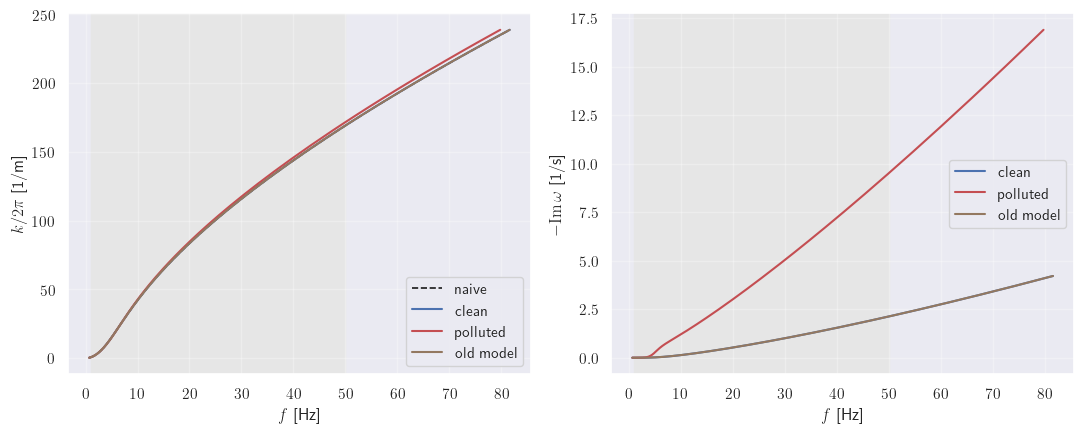

In [ ]:
mreload(dsp)
roots_clean    = dsp.dispersion_curve(ks, PARAMS_CLEAN,    method='newton', mode='deep', tol=1e-15)
roots_polluted = dsp.dispersion_curve(ks, PARAMS_POLLUTED, method='newton', mode='deep', tol=1e-15)

# old model
# See https://journals.aps.org/prfluids/pdf/10.1103/PhysRevFluids.3.124803 for details about the model.
def _complex_dispersion(omega, k):
    nu = PARAMS_POLLUTED['nu']
    g = PARAMS_POLLUTED['g']
    rho = PARAMS_POLLUTED['rho']
    T0 = PARAMS_POLLUTED['T0']
    
    lhs = (2 - 1j*omega/(nu*k**2))**2 + (k*(g + T0/rho * k**2)) / (nu**2 * k**4)
    rhs = 4 * np.sqrt(1 - 1j*omega/(nu*k**2))
    return lhs - rhs

# --- Solver for one k ---
def _solve_for_k(k):
    g = PARAMS_POLLUTED['g']
    rho = PARAMS_POLLUTED['rho']
    T0 = PARAMS_POLLUTED['T0']
    # initial guess: inviscid dispersion relation
    omega0 = np.sqrt(g*k + (T0/rho) * k**3)
    # solve numerically
    sol = sp.optimize.newton(func=lambda w: _complex_dispersion(w, k), x0=omega0, maxiter=1000, tol=1e-10)
    return sol

w_old = np.array([_solve_for_k(k) for k in ks])

# Take the +omega branch (first guess from inviscid_guess)
w_clean    = np.array([r[0] for r in roots_clean])
w_polluted = np.array([r[0] for r in roots_polluted])

w_naive = np.sqrt((PARAMS_CLEAN['g']*ks + PARAMS_CLEAN['T0']*ks**3/PARAMS_CLEAN['rho'])
                  * np.tanh(ks*PARAMS_CLEAN['H']))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].plot(w_naive/twopi, ks/twopi,         'k--', lw=1.2, label='naive')
ax[0].plot(w_clean.real/twopi, ks/twopi,    'C0-',         label='clean')
ax[0].plot(w_polluted.real/twopi, ks/twopi, 'C3-',         label='polluted')
ax[0].plot(w_old.real/twopi, ks/twopi,      'C5-',         label='old model')
ax[0].axvspan(1, 50, color='0.9', zorder=-1)
ax[0].set(xlabel=r'$f$ [Hz]', ylabel=r'$k/2\pi$ [1/m]')
ax[0].legend(); ax[0].grid(alpha=0.3, which='both')

ax[1].plot(w_clean.real/twopi, -w_clean.imag,       'C0-', label='clean')
ax[1].plot(w_polluted.real/twopi, -w_polluted.imag, 'C3-', label='polluted')
ax[1].plot(w_old.real/twopi, -w_old.imag,           'C5-', label='old model')
ax[1].axvspan(1, 50, color='0.9', zorder=-1)
ax[1].set(xlabel=r'$f$ [Hz]', ylabel=r'$-\mathrm{Im}\,\omega$ [1/s]')
ax[1].legend(); ax[1].grid(alpha=0.3, which='both')

fig.tight_layout()
plt.show()

mode = deep
r = (1505.0673111968579-1505.0676434078766j)
ke = 0.02
Ma * NxF = (238.6900108898017+238.05575256675172j)
diff * TxN = (-0.059767978454388526-0.016376031294093357j)

r = (1505.0673187221962-1505.0676509332131j)
ke = 0.02
Ma * NxF = (238.70437948244611+238.05575136851084j)
diff * TxN = (-1.5391385863608162-2.6123699046190363j)

r = (1505.0679013281995-1505.068692159917j)
ke = 0.02
Ma * NxF = (240.25458626670982+237.61778475601412j)
diff * TxN = (-240.25521379641333-237.6180931989136j)

r = (1505.067908853543-1505.0686996852564j)
ke = 0.02
Ma * NxF = (240.26895489063622+237.61778355341482j)
diff * TxN = (-241.7345952848975-240.21409819093435j)

r = (1505.0679013277397-1505.0686921574634j)
ke = 0.02
Ma * NxF = (240.2545834853771+237.6177866598421j)
diff * TxN = (-240.25458348685282-237.61778666243592j)

r = (1505.067908853083-1505.0686996828028j)
ke = 0.02
Ma * NxF = (240.26895210937394+237.6177854573132j)
diff * TxN = (-241.7339649851928-240.21379167178313j)

r = (1505.067311

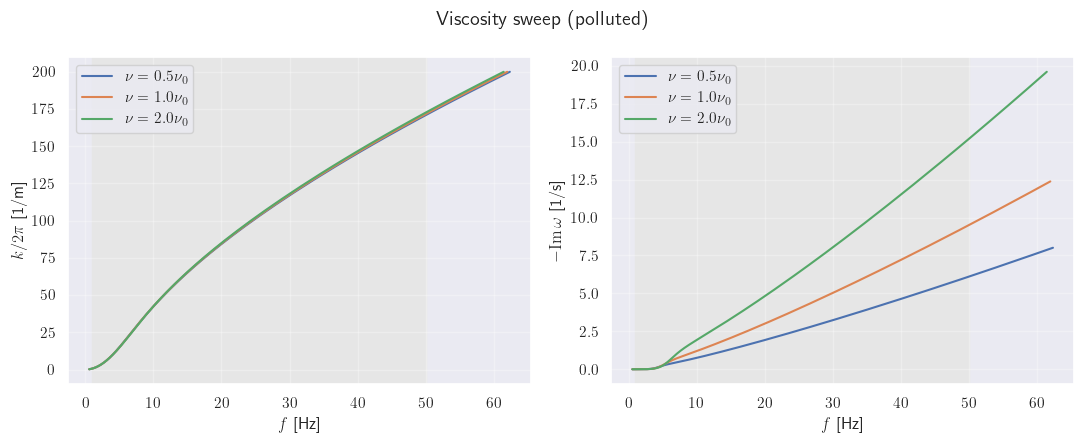

In [ ]:
mreload(dsp)
nu_factors = [0.5, 1.0, 2.0]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

for f in nu_factors:
    p = {**PARAMS_POLLUTED, 'nu': PARAMS_POLLUTED['nu'] * f}
    roots = dsp.dispersion_curve(ks, p, method='newton', mode='deep')
    w = np.array([r[0] for r in roots])
    ax[0].plot(w.real/(2*np.pi), ks/twopi, label=fr'$\nu = {f}\nu_0$')
    ax[1].plot(w.real/(2*np.pi), -w.imag,          label=fr'$\nu = {f}\nu_0$')

ax[0].axvspan(1, 50, color='0.9', zorder=-1)
ax[0].set(xlabel=r'$f$ [Hz]', ylabel=r'$k/2\pi$ [1/m]')
ax[1].axvspan(1, 50, color='0.9', zorder=-1)
ax[1].set(xlabel=r'$f$ [Hz]', ylabel=r'$-\mathrm{Im}\,\omega$ [1/s]')

fmt = FuncFormatter(lambda x, _: f'{x / 10**np.floor(np.log10(x)):.0f}')
for a in ax: 
    a.legend(); a.grid(alpha=0.3, which='both')
    a.xaxis.set_minor_formatter(fmt)
    a.yaxis.set_minor_formatter(fmt)
fig.suptitle('Viscosity sweep (polluted)')
fig.tight_layout(); plt.show()

mode = deep
{'H': 100, 'rho': 998.0127975779408, 'nu': 9.8137767548752e-07, 'g': 9.80665, 'T0': 0.0735, 'delT': 0.005, 'k_e': 0.0, 'D': 1e-10, 'kappa': 1e-05}
{'H': 100, 'rho': 998.0127975779408, 'nu': 9.8137767548752e-07, 'g': 9.80665, 'T0': 0.0735, 'delT': 0.005, 'k_e': 0.0, 'D': 1e-10, 'kappa': 1e-05}
mode = deep
{'H': 100, 'rho': 998.0127975779408, 'nu': 9.8137767548752e-07, 'g': 9.80665, 'T0': 0.0735, 'delT': 0.005, 'k_e': 0.02, 'D': 1e-10, 'kappa': 1e-05}
mode = deep
{'H': 100, 'rho': 998.0127975779408, 'nu': 9.8137767548752e-07, 'g': 9.80665, 'T0': 0.0735, 'delT': 0.005, 'k_e': 0.04, 'D': 1e-10, 'kappa': 1e-05}
mode = deep


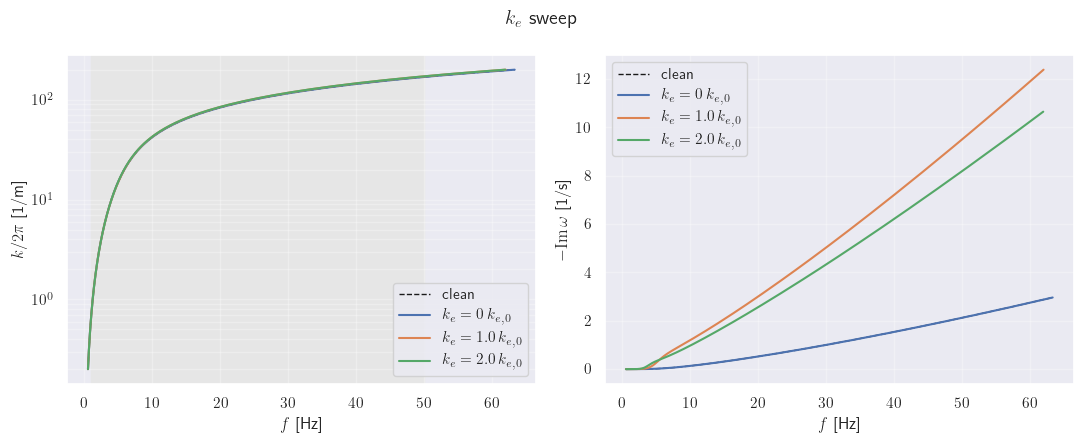

In [ ]:
mreload(dsp)

# various elastic modulus coefficients

ke_factors = [0, 1.0, 2.0]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# clean reference
roots_c = dsp.dispersion_curve(ks, PARAMS_CLEAN, method='newton', mode='deep')
w_c = np.array([r[0] for r in roots_c])
ax[0].semilogy(w_c.real/(2*np.pi), ks/twopi,        'k--', lw=1, label='clean')
ax[1].plot(w_c.real/(2*np.pi), -w_c.imag, 'k--', lw=1, label='clean')

print(PARAMS_CLEAN)
for f in ke_factors:
    p = {**PARAMS_POLLUTED, 'k_e': PARAMS_POLLUTED['k_e'] * f}
    print(p)
    roots = dsp.dispersion_curve(ks, p, method='newton', mode='deep')
    w = np.array([r[0] for r in roots])
    ax[0].semilogy(w.real/twopi, ks/twopi, label=fr'$k_e = {f}\,k_{{e,0}}$')
    ax[1].plot(w.real/twopi, -w.imag,          label=fr'$k_e = {f}\,k_{{e,0}}$')

ax[0].axvspan(1, 50, color='0.9', zorder=-1)
ax[0].set(xlabel=r'$f$ [Hz]', ylabel=r'$k/2\pi$ [1/m]')
ax[1].set(xlabel=r'$f$ [Hz]', ylabel=r'$-\mathrm{Im}\,\omega$ [1/s]')
for a in ax: a.legend(); a.grid(alpha=0.3, which='both')
fig.suptitle(r'$k_e$ sweep')
fig.tight_layout(); plt.show()

mode = deep
{'H': 100, 'rho': 998.0127975779408, 'nu': 9.8137767548752e-07, 'g': 9.80665, 'T0': 0.0735, 'delT': 0.005, 'k_e': 0.0, 'D': 1e-10, 'kappa': 1e-05}
mode = deep
{'H': 100, 'rho': 998.0127975779408, 'nu': 9.8137767548752e-07, 'g': 9.80665, 'T0': 0.0735, 'delT': 0.005, 'k_e': 0.02, 'D': 1e-10, 'kappa': 1e-05}
mode = deep
{'H': 100, 'rho': 998.0127975779408, 'nu': 9.8137767548752e-07, 'g': 9.80665, 'T0': 0.0735, 'delT': 0.005, 'k_e': 0.04, 'D': 1e-10, 'kappa': 1e-05}
mode = deep
{'H': 100, 'rho': 998.0127975779408, 'nu': 9.8137767548752e-07, 'g': 9.80665, 'T0': 0.0735, 'delT': 0.005, 'k_e': 2.0, 'D': 1e-10, 'kappa': 1e-05}
mode = deep
{'H': 100, 'rho': 998.0127975779408, 'nu': 9.8137767548752e-07, 'g': 9.80665, 'T0': 0.0735, 'delT': 0.005, 'k_e': 200.0, 'D': 1e-10, 'kappa': 1e-05}
mode = deep


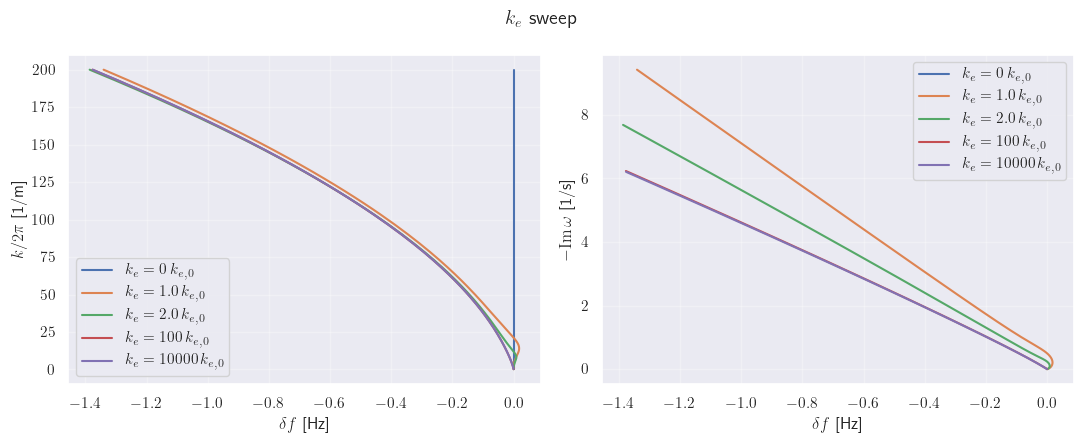

In [ ]:
mreload(dsp)

# various elastic modulus coefficients

ke_factors = [0, 1.0, 2.0, 100, 10000]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# clean reference
roots_c = dsp.dispersion_curve(ks, PARAMS_CLEAN, method='newton', mode='deep')
w_c = np.array([r[0] for r in roots_c])

for f in ke_factors:
    p = {**PARAMS_POLLUTED, 'k_e': PARAMS_POLLUTED['k_e'] * f}
    print(p)
    roots = dsp.dispersion_curve(ks, p, method='newton', mode='deep')
    w = np.array([r[0] for r in roots])
    ax[0].plot((w-w_c).real/twopi, ks/twopi, label=fr'$k_e = {f}\,k_{{e,0}}$')
    ax[1].plot((w-w_c).real/twopi, -(w-w_c).imag,  label=fr'$k_e = {f}\,k_{{e,0}}$')

# ax[0].axvspan(1, 50, color='0.9', zorder=-1)
ax[0].set(xlabel=r'$\delta f$ [Hz]', ylabel=r'$k/2\pi$ [1/m]')
ax[1].set(xlabel=r'$\delta f$ [Hz]', ylabel=r'$-\mathrm{Im}\,\omega$ [1/s]')
for a in ax: a.legend(); a.grid(alpha=0.3, which='both')
fig.suptitle(r'$k_e$ sweep')
fig.tight_layout(); plt.show()

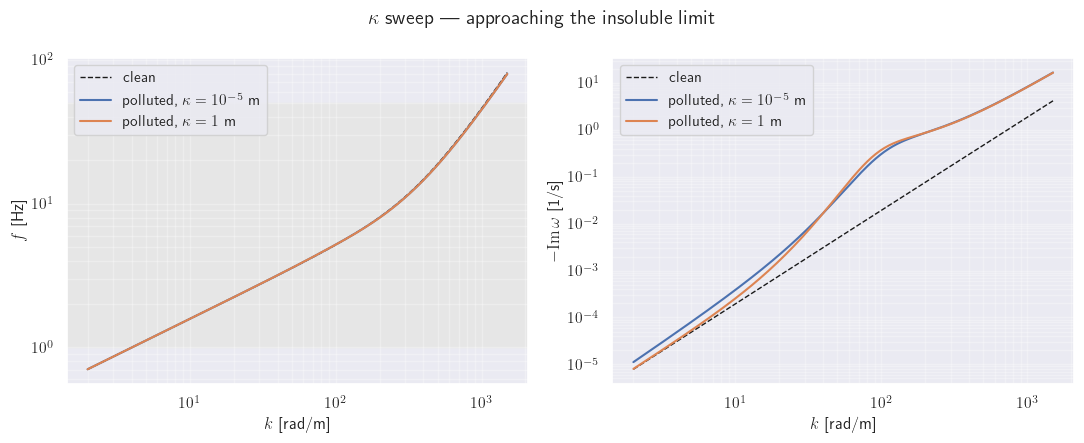

In [10]:
# extreme kappa

variants = {
    fr'polluted, $\kappa=10^{{-5}}$ m':   PARAMS_POLLUTED,
    fr'polluted, $\kappa=1$ m':           {**PARAMS_POLLUTED, 'kappa': 1.0},
}

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# clean reference
roots_c = dispersion_curve(ks, PARAMS_CLEAN, method='newton')
w_c = np.array([r[0] for r in roots_c])
ax[0].loglog(ks, w_c.real/(2*np.pi), 'k--', lw=1, label='clean')
ax[1].loglog(ks, -w_c.imag,          'k--', lw=1, label='clean')

for label, p in variants.items():
    roots = dispersion_curve(ks, p, method='newton')
    w = np.array([r[0] for r in roots])
    ax[0].loglog(ks, w.real/(2*np.pi), label=label)
    ax[1].loglog(ks, -w.imag,          label=label)

ax[0].axhspan(1, 50, color='0.9', zorder=-1)
ax[0].set(xlabel=r'$k$ [rad/m]', ylabel=r'$f$ [Hz]')
ax[1].set(xlabel=r'$k$ [rad/m]', ylabel=r'$-\mathrm{Im}\,\omega$ [1/s]')
for a in ax: a.legend(); a.grid(alpha=0.3, which='both')
fig.suptitle(r'$\kappa$ sweep — approaching the insoluble limit')
fig.tight_layout(); plt.show()

mode = deep
ke = 0.02
Ma * NxF = (119.34497903541266+118.89652159365158j)
diff * TxN = (-0.08452470050092678-0.023159148869207457j)

ke = 0.02
Ma * NxF = (119.35005892526642+118.8965209935899j)
diff * TxN = (-0.824210741436846-1.3211555954424778j)

ke = 0.02
Ma * NxF = (119.89739596190158+118.74236649949047j)
diff * TxN = (-119.89770866413892-118.74252076006042j)

ke = 0.02
Ma * NxF = (119.90247586282489+118.74236589786959j)
diff * TxN = (-120.6374001378987-120.04052276903059j)

ke = 0.02
Ma * NxF = (119.89739498016378+118.74236716772246j)
diff * TxN = (-119.89739498112613-118.74236716945765j)

ke = 0.02
Ma * NxF = (119.90247488105186+118.74236656610162j)
diff * TxN = (-120.63708644994293-120.0403691697695j)

ke = 0.02
Ma * NxF = (119.34497903541266-118.89652159365158j)
diff * TxN = (-0.08452470050092678+0.023159148869207457j)

ke = 0.02
Ma * NxF = (119.33989914556098-118.89652219376609j)
diff * TxN = (0.655161323167146-1.274837272985716j)

ke = 0.02
Ma * NxF = (119.89739597273345-118.

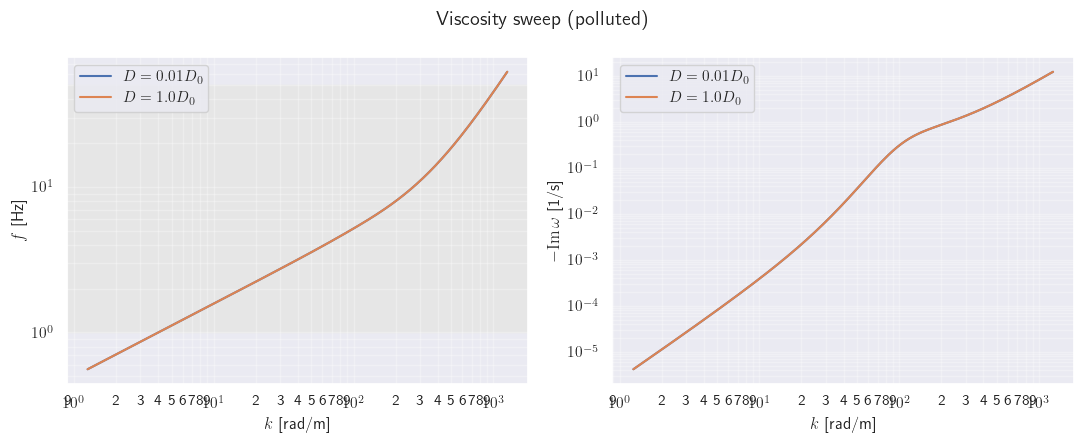

In [142]:
mreload(dsp)
D_factors = [0.01, 1.0]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

for f in D_factors:
    p = {**PARAMS_POLLUTED, 'D': PARAMS_POLLUTED['D'] * f, 'kappa': PARAMS_POLLUTED['kappa'] * np.sqrt(f)}
    roots = dsp.dispersion_curve(ks, p, method='newton', mode='deep')
    w = np.array([r[0] for r in roots])
    ax[0].loglog(ks, w.real/(2*np.pi), label=fr'$D = {f}D_0$')
    ax[1].loglog(ks, -w.imag,          label=fr'$D = {f}D_0$')

ax[0].axhspan(1, 50, color='0.9', zorder=-1)
ax[0].set(xlabel=r'$k$ [rad/m]', ylabel=r'$f$ [Hz]')
ax[1].set(xlabel=r'$k$ [rad/m]', ylabel=r'$-\mathrm{Im}\,\omega$ [1/s]')

fmt = FuncFormatter(lambda x, _: f'{x / 10**np.floor(np.log10(x)):.0f}')
for a in ax: 
    a.legend(); a.grid(alpha=0.3, which='both')
    a.xaxis.set_minor_formatter(fmt)
    # a.yaxis.set_minor_formatter(fmt)
fig.suptitle('Viscosity sweep (polluted)')
fig.tight_layout(); plt.show()

In [ ]:
dsp.det_dispersion_deep()